In [10]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

sns.set(style="whitegrid")

# ================================
# 2. Load Dataset
# ================================
df = pd.read_csv(r'C:\Users\FA23-BCS-041.CUI\Desktop\datasets\Loan_default.csv')

print("Shape:", df.shape)
print("Columns:", df.columns)
print(df.head())


Shape: (255347, 18)
Columns: Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='str')
       LoanID  Age  Income  LoanAmount  CreditScore  MonthsEmployed  \
0  I38PQUQS96   56   85994       50587          520              80   
1  HPSK72WA7R   69   50432      124440          458              15   
2  C1OZ6DPJ8Y   46   84208      129188          451              26   
3  V2KKSFM3UN   32   31713       44799          743               0   
4  EY08JDHTZP   60   20437        9139          633               8   

   NumCreditLines  InterestRate  LoanTerm  DTIRatio    Education  \
0               4         15.23        36      0.44   Bachelor's   
1               1          4.81        60      0.68     Master's   
2               3         21.17 

In [12]:
# ================================
# 3. Data Cleaning
# ================================

# Drop ID column if exists
if 'LoanID' in df.columns:
    df.drop('LoanID', axis=1, inplace=True)

# Missing values check
print("\nMissing Values:\n", df.isnull().sum())

# Fill numeric missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

# Fill categorical missing values (FIXED WARNING VERSION)
for col in df.select_dtypes(include=['object', 'string']):
    df[col] = df[col].fillna(df[col].mode()[0])


Missing Values:
 Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64


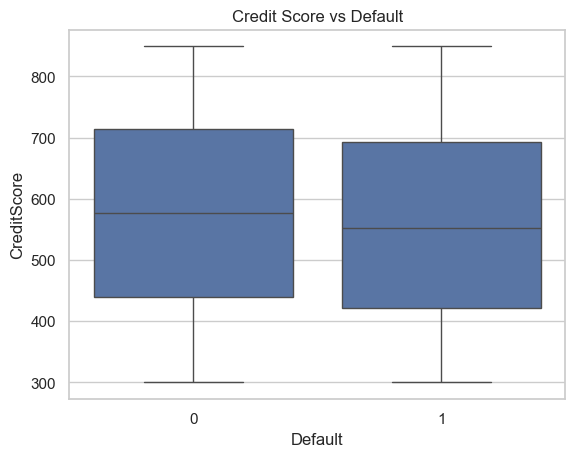

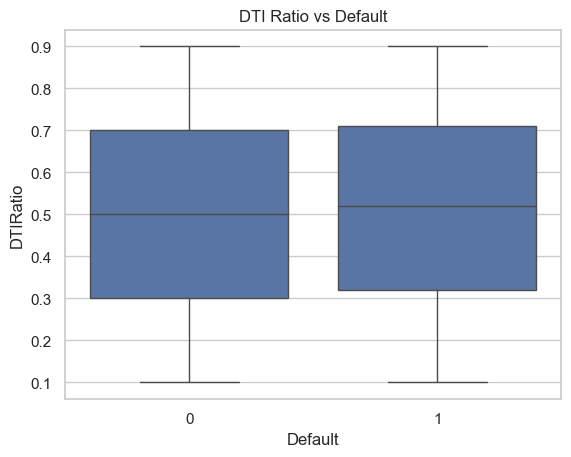

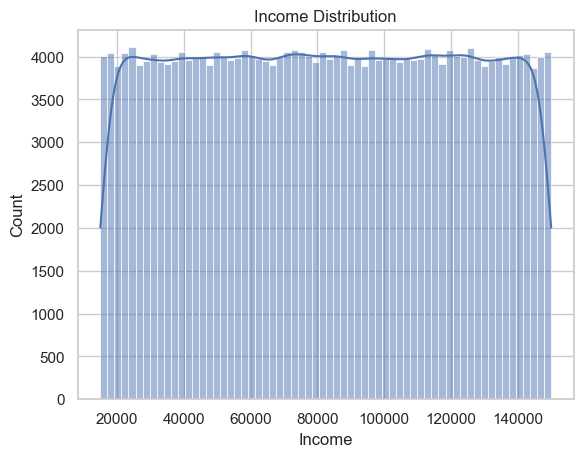

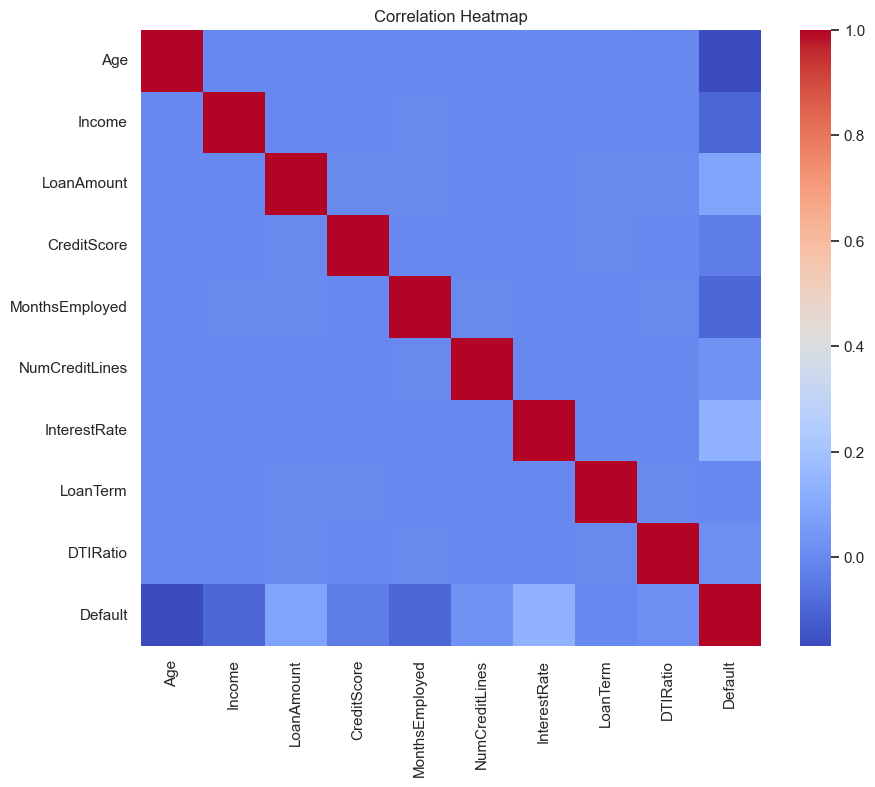

In [13]:
# ================================
# 4. Exploratory Data Analysis (EDA)
# ================================

plt.figure()
sns.boxplot(x='Default', y='CreditScore', data=df)
plt.title("Credit Score vs Default")
plt.show()

plt.figure()
sns.boxplot(x='Default', y='DTIRatio', data=df)
plt.title("DTI Ratio vs Default")
plt.show()

plt.figure()
sns.histplot(df['Income'], kde=True)
plt.title("Income Distribution")
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [14]:
# ================================
# 5. Convert Categorical to Numeric
# ================================
df = pd.get_dummies(df, drop_first=True)

# ================================
# 6. Split Data
# ================================
X = df.drop('Default', axis=1)
y = df['Default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================================
# 7. Feature Scaling (IMPORTANT FIX)
# ================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ================================
# 8. Train Models
# ================================

# Logistic Regression (USES SCALED DATA)
lr = LogisticRegression(max_iter=5000)
lr.fit(X_train_scaled, y_train)

# Decision Tree (NO SCALING NEEDED)
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# ================================
# 9. Predictions
# ================================
y_pred_lr = lr.predict(X_test_scaled)
y_pred_dt = dt.predict(X_test)

# ================================
# 10. Evaluation
# ================================

print("\n🔹 Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("🔹 Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

print("\n🔹 Logistic Regression Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("\n🔹 Decision Tree Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))



🔹 Logistic Regression Accuracy: 0.885823379674956
🔹 Decision Tree Accuracy: 0.8027021734873703

🔹 Logistic Regression Confusion Matrix:
 [[45046   124]
 [ 5707   193]]

🔹 Decision Tree Confusion Matrix:
 [[39619  5551]
 [ 4525  1375]]


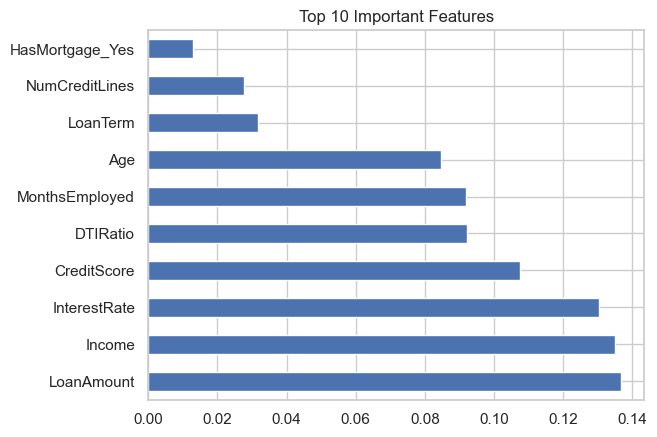

In [15]:
# ================================
# 11. Feature Importance (Decision Tree)
# ================================
importances = pd.Series(dt.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.show()